In [1]:
import pandas as pd

df = pd.read_pickle('electronika_clean.pkl')
df

,Unnamed: 0,Order_ID,Email_new,Phone_new,Source,OrderDate,время,месяц,ChangeDate,DeliveryDate,...,Quant,RowPrice,RowDiscount,RowSum,Brand,TN,TK,NomFullPath,Week,Nom_ID
0,10,1303000511_TT,556669108109_lm16@gmail.com,55574953-52525755535375,Онлайн-Резерв.,2016-03-01,10:46:45.000,201603,2016-03-05 09:16:49.000,2016-03-01 00:00:00.000,...,1,2970,0,2970,Ника,Товары для дома,Хозтовары,Техника для дома/Техника для ухода за одеждой/...,9,90364
1,12,1303000512_TT,556669108109_lm16@gmail.com,55574953-52525755535375,Онлайн-Резерв.,2016-03-01,10:47:19.000,201603,2016-03-01 10:59:43.000,2016-03-01 00:00:00.000,...,1,19490,0,19490,DeLonghi,Мелкая бытовая техника,Приготовление пищи,Техника для кухни/Приготовление пищи/Мультиварки/,9,45673
2,14,1303000513_TT,666668112117_pu19@ya.ru,55575655-50555350534877,Онлайн-Резерв.,2016-03-11,16:06:56.000,201603,2016-03-11 20:11:18.000,2016-03-12 00:00:00.000,...,1,19990,0,19990,Samsung,ТВ-Аудио,Телевизоры LCD,"Телевизоры, аудио, видео/Телевизоры/LED телеви...",10,120757
3,16,1303000514_TT,666668112117_pu19@ya.ru,55575653-57485657505272,Онлайн-Резерв.,2016-03-15,18:13:33.000,201603,2016-03-15 18:17:35.000,2016-03-22 00:00:00.000,...,1,23680,0,23680,СМК,Мебель,Мягкая мебель,Мебель/Мягкая мебель/Диваны/Трехместные диваны/,11,264580
4,28,1303000520_TT,56666668112117_pu26@yanded.ru,55575449-54535553535073,Онлайн-Резерв.,2016-03-01,00:01:46.000,201603,2016-03-04 15:09:38.000,2016-03-02 00:00:00.000,...,1,2420,0,2420,HP,Аксессуары,Картриджи и бумага,"Компьютеры, ноутбуки, планшеты/Оргтехника/Расх...",9,76102
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183067,357019,5898089_BX,6666449117_1u9@bk.ru,55574957-51495048515075,Онлайн-Резерв.,2016-04-30,23:51:37.000,201604,2016-05-03 12:55:07.000,2016-05-02 00:00:00.000,...,1,899,0,899,Saturn,Климат,Вентиляторы бытовые,Техника для дома/Климатическая техника/Кондици...,17,38755
183068,357021,5898095_BX,666661118109_vm27@yahoo.com,55575452-55554849505278,Онлайн-Резерв.,2016-04-30,23:54:03.000,201604,2016-05-04 19:43:40.000,2016-05-07 00:00:00.000,...,1,1090,0,1090,Case Logic,Аксессуары,Аксессуары для фото/видео,Фото- и видеотехника/Аксессуары для фото и вид...,17,31908
183069,357023,5898099_BX,3110116_nt16@pisem.net,55574948-50554849554878,Онлайн-Резерв.,2016-04-30,23:56:02.000,201604,2016-05-01 11:57:42.000,2016-05-08 00:00:00.000,...,1,6859,0,6859,ELIKOR,Крупная бытовая техника,Встраиваемая техника,Встраиваемая техника/Вытяжки/,17,140459
183070,357024,5898102_BX,55666665102117_fu13@list.ru,55575648-51484956545071,Онлайн-Резерв.,2016-04-30,23:56:38.000,201604,2016-05-06 20:18:49.000,2016-05-05 00:00:00.000,...,1,9120,0,9120,FORWARD,Спорт и активный отдых,Велосипеды и аксессуары,Товары для спорта и отдыха/Велосипеды и аксесс...,17,295956


In [2]:
from prophet import Prophet
import matplotlib.pyplot as plt
import seaborn as sns

# Крупная бытовая техника

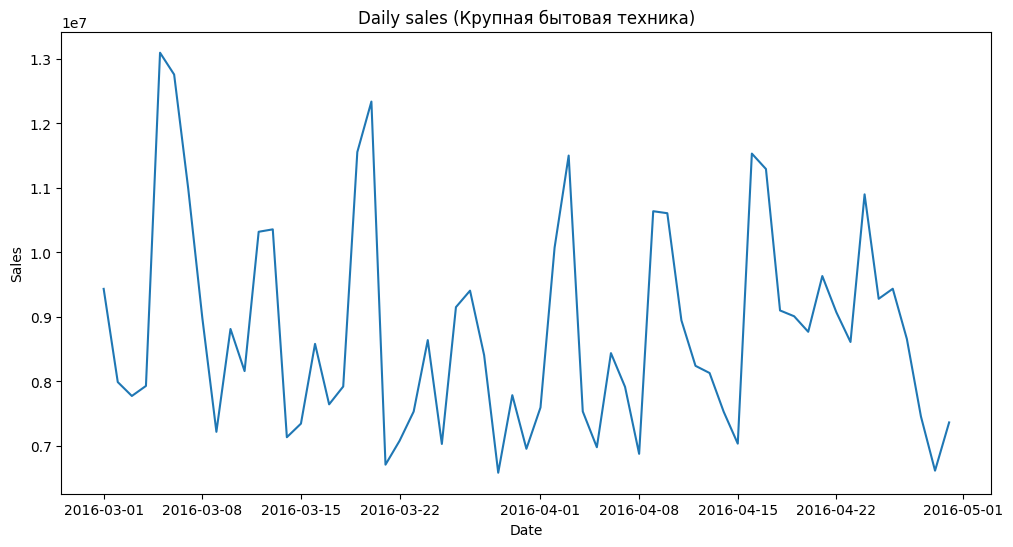

In [3]:
category_name = 'Крупная бытовая техника'
daily_sales = df[df['TN'] == f'{category_name}'][['OrderDate', 'RowSum']]\
    .groupby('OrderDate').sum()\
    .resample('D').sum()
daily_sales.reset_index(inplace=True)
daily_sales.rename(columns={'OrderDate': 'ds', 'RowSum': 'y'}, inplace=True)
daily_sales.sort_values(by='ds', inplace=True)

plt.figure(figsize=(12, 6))
sns.lineplot(data=daily_sales, x='ds', y='y')
plt.title(f"Daily sales ({category_name})")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

16:11:57 - cmdstanpy - INFO - Chain [1] start processing
16:11:57 - cmdstanpy - INFO - Chain [1] done processing


,yhat,yhat_lower,yhat_upper,y
ds,,,,
2016-03-01,8.316175e+06,7.197183e+06,9.487579e+06,9432195
2016-03-02,8.462294e+06,7.183774e+06,9.600203e+06,7986991
2016-03-03,8.403601e+06,7.205379e+06,9.534725e+06,7771378
2016-03-04,8.013640e+06,6.871647e+06,9.117719e+06,7927095
2016-03-05,1.141613e+07,1.027074e+07,1.252658e+07,13094042
...,...,...,...,...
2016-04-26,6.978560e+06,5.716897e+06,8.185771e+06,9434044
2016-04-27,7.126156e+06,5.981318e+06,8.273598e+06,8655956
2016-04-28,7.068938e+06,5.906842e+06,8.223913e+06,7453044


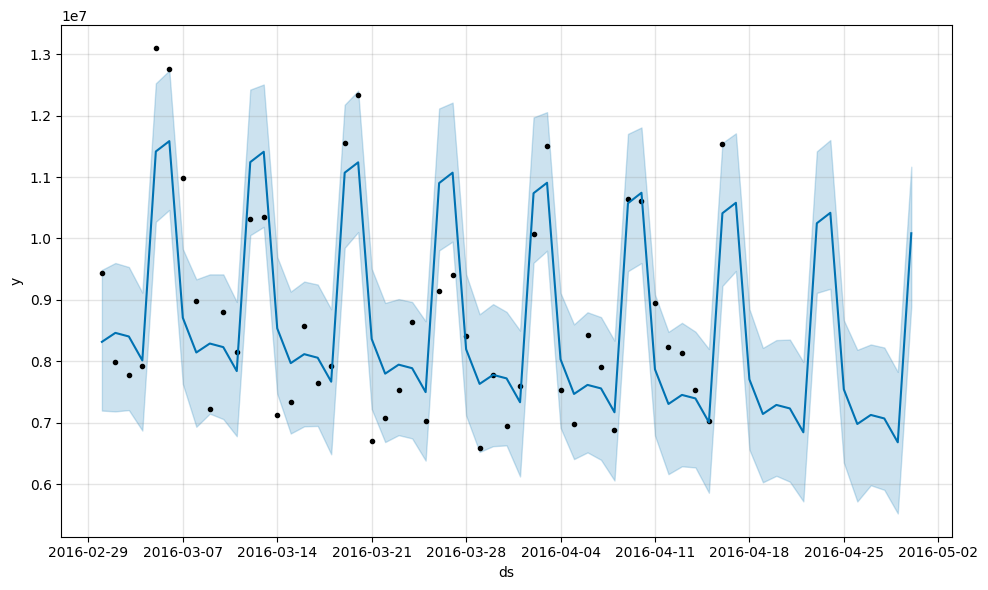

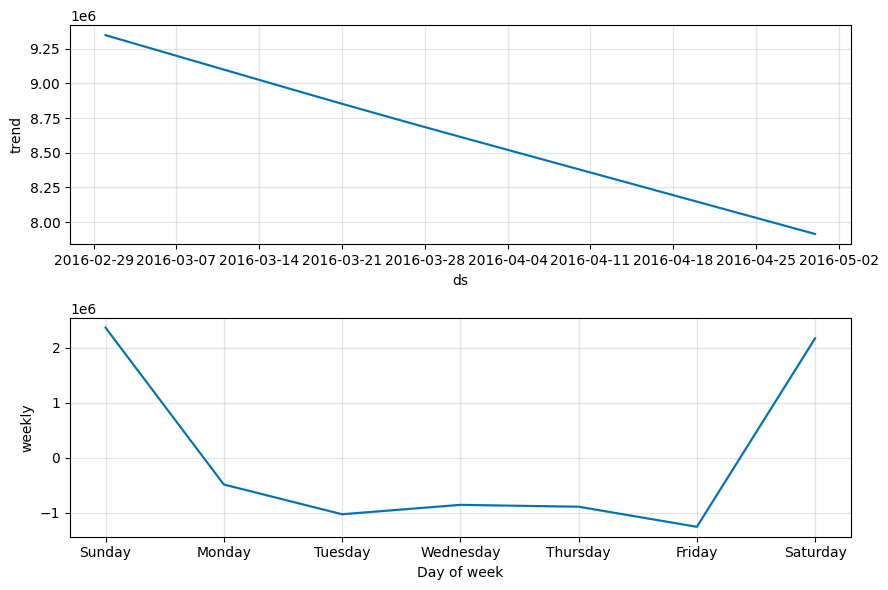

In [4]:
from sklearn.metrics import mean_absolute_percentage_error

model = Prophet()
model.fit(daily_sales[:-14])
future = model.make_future_dataframe(periods=14)
forecast = model.predict(future)
model.plot(forecast)
model.plot_components(forecast)
cmp_df = forecast.set_index('ds')[['yhat', 'yhat_lower', 'yhat_upper']].join(daily_sales.set_index('ds'))
cmp_df

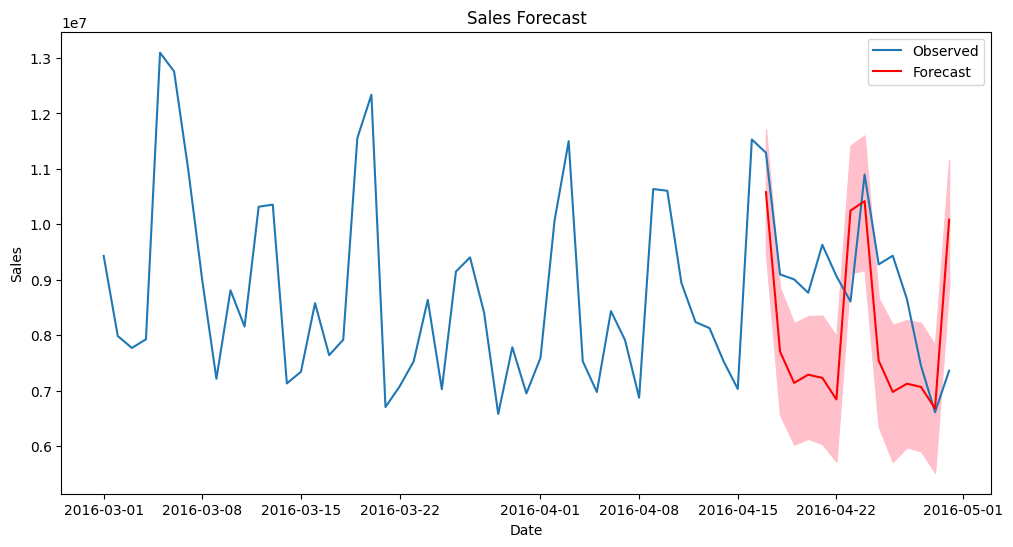

MAPE: 8.381023029150462


In [5]:
from sklearn.metrics import mean_absolute_percentage_error

# Plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(cmp_df[['y']], label='Observed')
plt.plot(cmp_df[['yhat']][-14:], label='Forecast', color='red')
plt.fill_between(cmp_df[-14:].index, cmp_df['yhat_lower'][-14:], cmp_df['yhat_upper'][-14:], color='pink')
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

mape = mean_absolute_percentage_error(cmp_df['y'][:-14], cmp_df['yhat'][:-14]) * 100.0
print(f'MAPE: {mape}')

# Мелкая бытовая техника

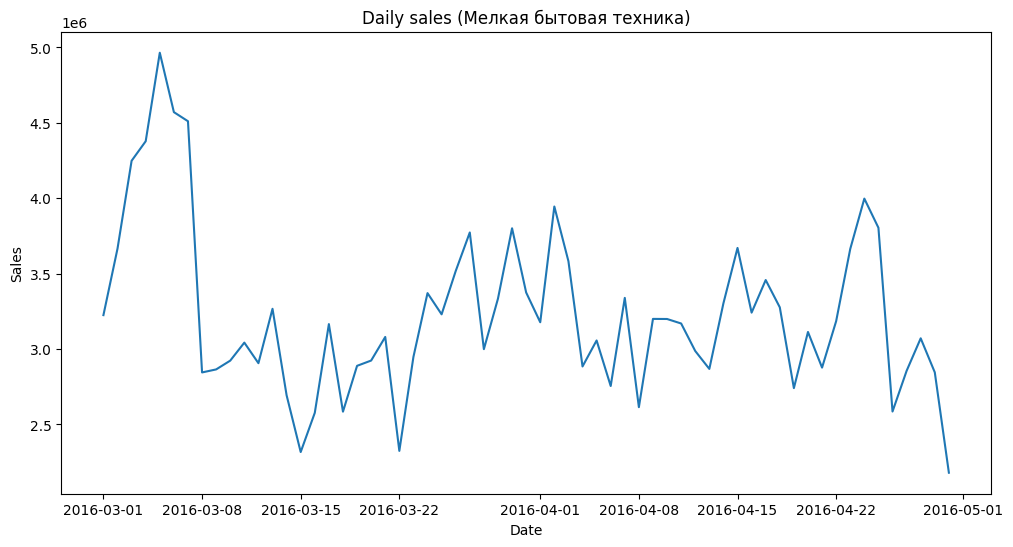

In [6]:
category_name = 'Мелкая бытовая техника'
daily_sales = df[df['TN'] == f'{category_name}'][['OrderDate', 'RowSum']]\
    .groupby('OrderDate').sum()\
    .resample('D').sum()
daily_sales.reset_index(inplace=True)
daily_sales.rename(columns={'OrderDate': 'ds', 'RowSum': 'y'}, inplace=True)
daily_sales.sort_values(by='ds', inplace=True)

plt.figure(figsize=(12, 6))
sns.lineplot(data=daily_sales, x='ds', y='y')
plt.title(f"Daily sales ({category_name})")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

16:12:10 - cmdstanpy - INFO - Chain [1] start processing
16:12:10 - cmdstanpy - INFO - Chain [1] done processing


,yhat,yhat_lower,yhat_upper,y
ds,,,,
2016-03-01,3.109979e+06,2.471599e+06,3.748626e+06,3224024
2016-03-02,3.308308e+06,2.700449e+06,3.923664e+06,3665191
2016-03-03,3.628798e+06,2.999141e+06,4.264803e+06,4247324
2016-03-04,3.481989e+06,2.854084e+06,4.087733e+06,4376917
2016-03-05,3.762442e+06,3.132458e+06,4.362292e+06,4963810
...,...,...,...,...
2016-04-26,2.473050e+06,1.808894e+06,3.113858e+06,2584894
2016-04-27,2.671632e+06,2.053621e+06,3.307230e+06,2854585
2016-04-28,2.992373e+06,2.313540e+06,3.620202e+06,3070329


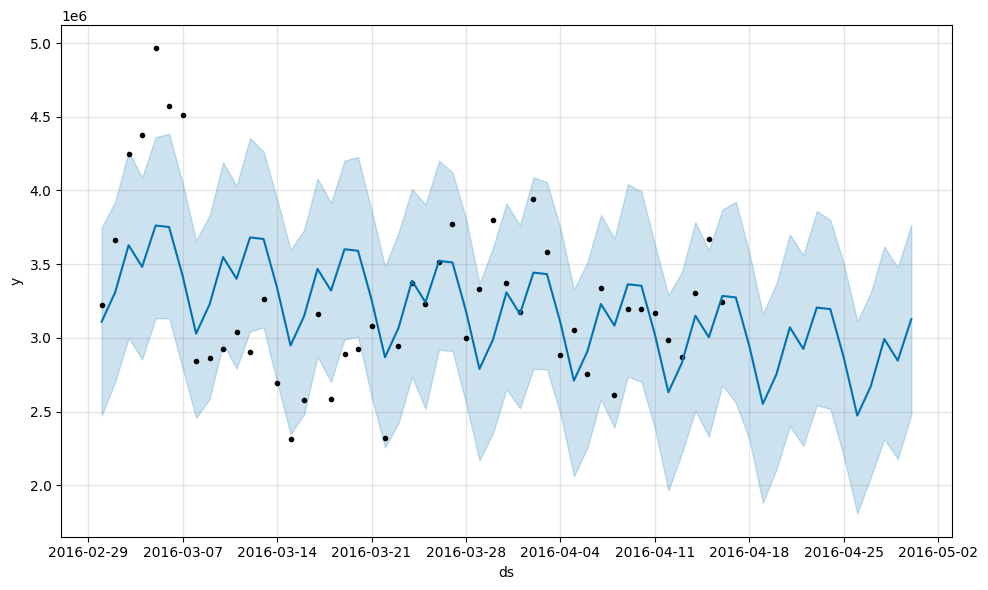

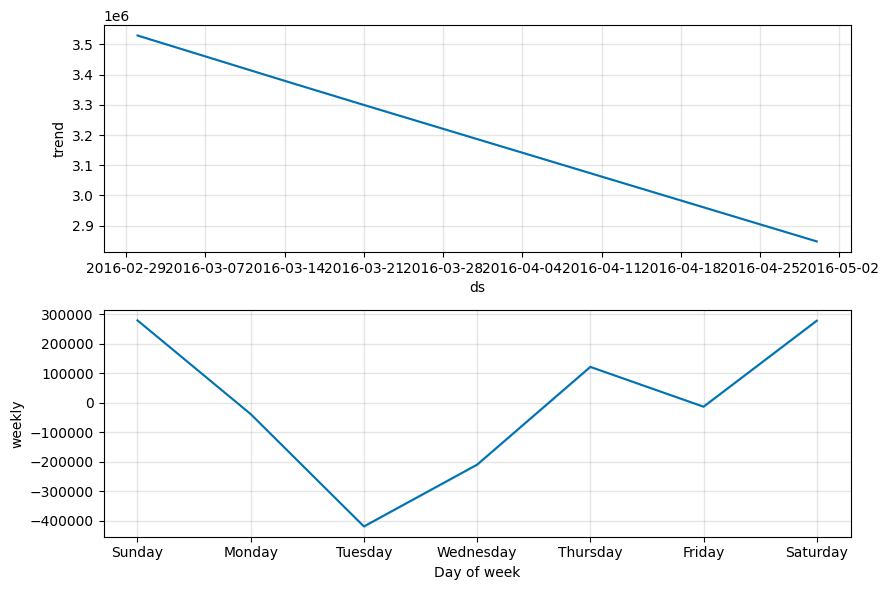

In [7]:
from sklearn.metrics import mean_absolute_percentage_error

model = Prophet()
model.fit(daily_sales[:-14])
future = model.make_future_dataframe(periods=14)
forecast = model.predict(future)
model.plot(forecast)
model.plot_components(forecast)
cmp_df = forecast.set_index('ds')[['yhat', 'yhat_lower', 'yhat_upper']].join(daily_sales.set_index('ds'))
cmp_df

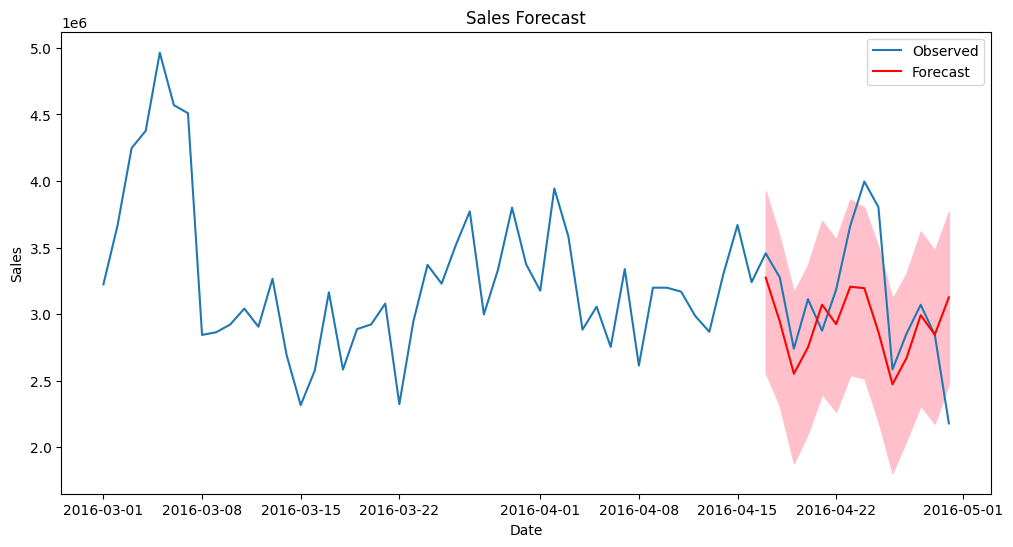

MAPE: 12.070211771683436


In [8]:
from sklearn.metrics import mean_absolute_percentage_error

# Plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(cmp_df[['y']], label='Observed')
plt.plot(cmp_df[['yhat']][-14:], label='Forecast', color='red')
plt.fill_between(cmp_df[-14:].index, cmp_df['yhat_lower'][-14:], cmp_df['yhat_upper'][-14:], color='pink')
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

mape = mean_absolute_percentage_error(cmp_df['y'][:-14], cmp_df['yhat'][:-14]) * 100.0
print(f'MAPE: {mape}')

# Сделай Сам

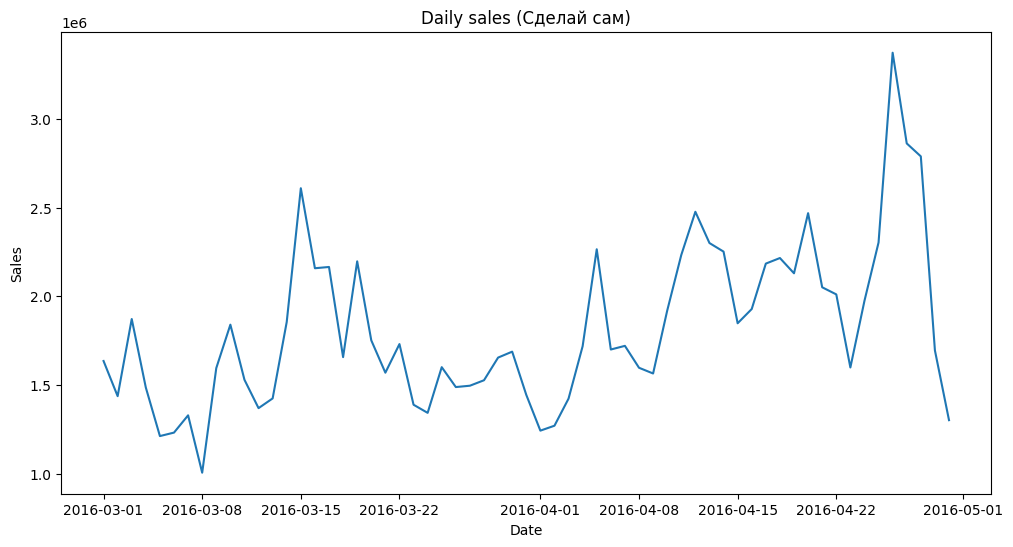

In [9]:
category_name = 'Сделай сам'
daily_sales = df[df['TN'] == f'{category_name}'][['OrderDate', 'RowSum']]\
    .groupby('OrderDate').sum()\
    .resample('D').sum()
daily_sales.reset_index(inplace=True)
daily_sales.rename(columns={'OrderDate': 'ds', 'RowSum': 'y'}, inplace=True)
daily_sales.sort_values(by='ds', inplace=True)

plt.figure(figsize=(12, 6))
sns.lineplot(data=daily_sales, x='ds', y='y')
plt.title(f"Daily sales ({category_name})")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

16:12:23 - cmdstanpy - INFO - Chain [1] start processing


16:12:24 - cmdstanpy - INFO - Chain [1] done processing


,yhat,yhat_lower,yhat_upper,y
ds,,,,
2016-03-01,1.692774e+06,1.310828e+06,2.052235e+06,1635392
2016-03-02,1.534159e+06,1.148010e+06,1.900351e+06,1436973
2016-03-03,1.587100e+06,1.167630e+06,1.967125e+06,1872283
2016-03-04,1.347297e+06,9.688194e+05,1.747476e+06,1485503
2016-03-05,1.357356e+06,9.585637e+05,1.743310e+06,1211762
...,...,...,...,...
2016-04-26,2.276886e+06,1.934404e+06,2.661487e+06,3374833
2016-04-27,2.118271e+06,1.722060e+06,2.516802e+06,2863092
2016-04-28,2.171212e+06,1.800629e+06,2.552735e+06,2789969


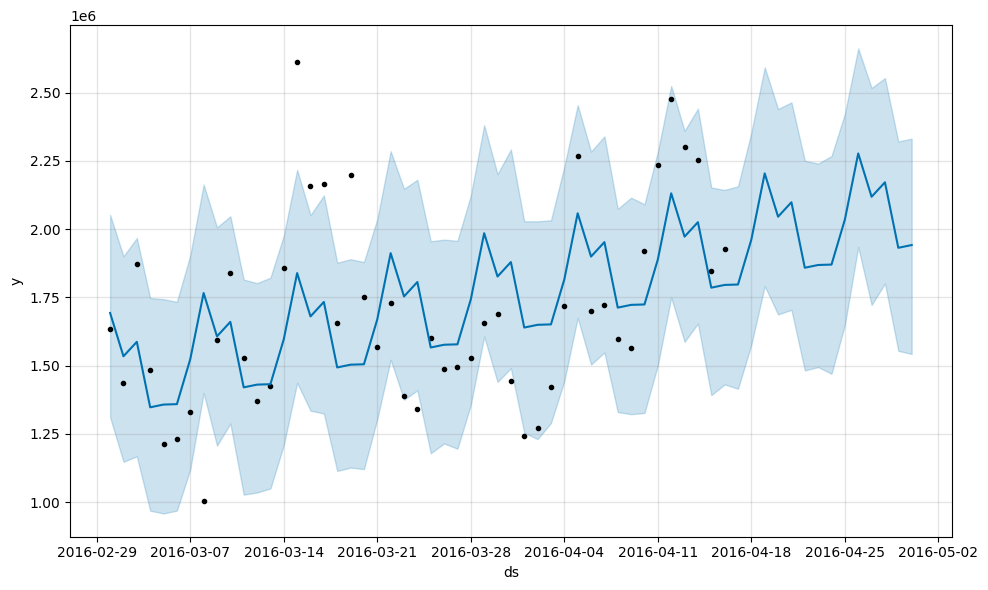

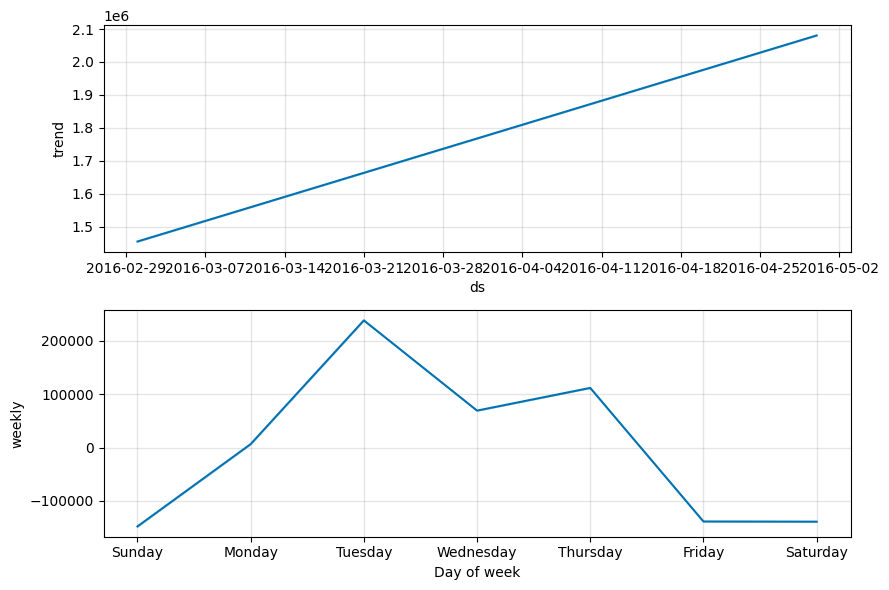

In [10]:
from sklearn.metrics import mean_absolute_percentage_error

model = Prophet()
model.fit(daily_sales[:-14])
future = model.make_future_dataframe(periods=14)
forecast = model.predict(future)
model.plot(forecast)
model.plot_components(forecast)
cmp_df = forecast.set_index('ds')[['yhat', 'yhat_lower', 'yhat_upper']].join(daily_sales.set_index('ds'))
cmp_df

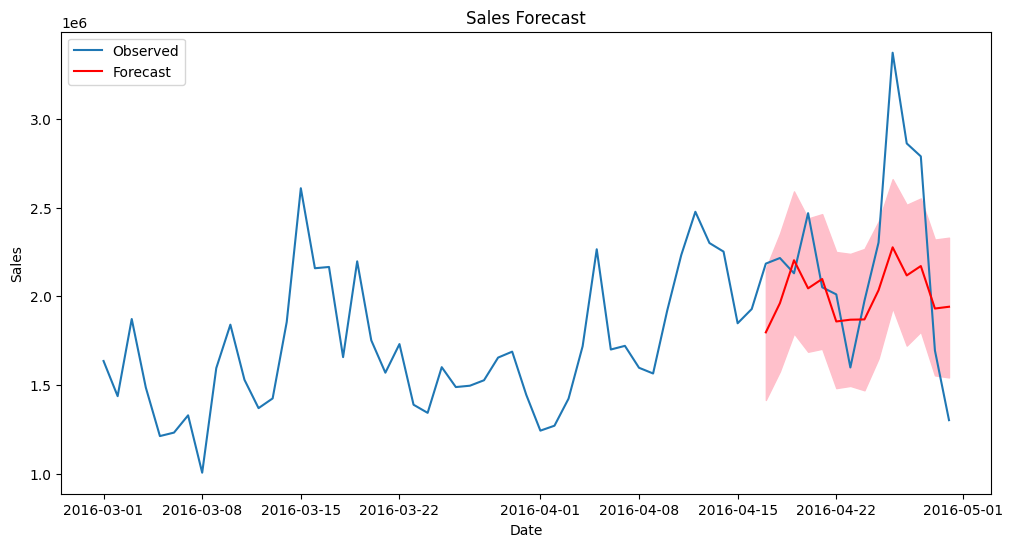

MAPE: 14.560287598959945


In [11]:
from sklearn.metrics import mean_absolute_percentage_error

# Plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(cmp_df[['y']], label='Observed')
plt.plot(cmp_df[['yhat']][-14:], label='Forecast', color='red')
plt.fill_between(cmp_df[-14:].index, cmp_df['yhat_lower'][-14:], cmp_df['yhat_upper'][-14:], color='pink')
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

mape = mean_absolute_percentage_error(cmp_df['y'][:-14], cmp_df['yhat'][:-14]) * 100.0
print(f'MAPE: {mape}')